# LLAT polar — 訓練分析

| | baseline(學姊) | mine(本次) |
|---|---|---|
| 變數 | u / v | **vt / vr** |
| 網格 | R=201(Δr 0.05°) | **R=41(Δr 0.25°)** |
| 精度 | fp32 | **bf16-mixed** |
| 等效批次 | 4 | **32(8×H200)** |
| max_steps | 1,600,000(只跑 15.8%) | **105,000(跑滿)** |
| 峰值 LR | 4e-4 | 4e-4 |
| 牆鐘 | 8.32 天 | **6.7 小時** |

⚠️ **val_loss 不可直接比較** —— 變數表與網格不同,loss 的尺度與平均對象不一樣。
可直接比較的是:**LR 是否完成退火、訓練穩定性、吞吐**。

In [9]:
import csv, numpy as np, matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": .3})
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def load(path):
    out = {}
    with open(path, newline="") as f:
        rd = csv.DictReader(f)
        for c in rd.fieldnames:
            out[c] = []
        for r in rd:
            for c in rd.fieldnames:
                v = r[c]
                out[c].append(float(v) if v not in ("", None) else np.nan)
    return {c: np.array(v) for c, v in out.items()}


def ser(d, col):
    """回傳該欄非 NaN 的 (step, value)"""
    m = ~np.isnan(d[col])
    return d["step"][m], d[col][m]


mine = load("run_mine_curves.csv")
base = load("run_baseline_curves.csv")

for n, d in (("mine", mine), ("baseline", base)):
    s, v = ser(d, "val_loss")
    print(f"{n:9s} val_loss {len(v):5d} 點  首 {v[0]:.5f}  末 {v[-1]:.5f}  "
          f"最佳 {v.min():.5f} @ step {int(s[v.argmin()])}")

mine      val_loss   231 點  首 0.35849  末 0.33168  最佳 0.30065 @ step 2269
baseline  val_loss    70 點  首 0.32564  末 0.29284  最佳 0.29061 @ step 239645


## 圖 1:損失曲線(對數座標才看得到 spike)

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

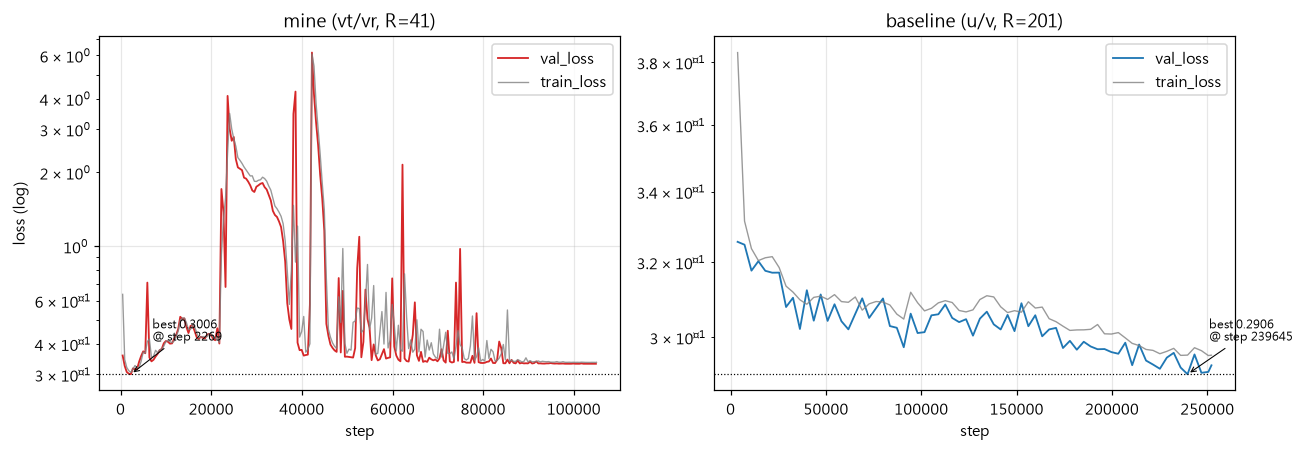

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for i, (n, d, c) in enumerate([("mine (vt/vr, R=41)", mine, "tab:red"),
                               ("baseline (u/v, R=201)", base, "tab:blue")]):
    s, v = ser(d, "val_loss")
    st, vt = ser(d, "train_loss_epoch")
    ax[i].semilogy(s, v, c=c, lw=1.2, label="val_loss")
    ax[i].semilogy(st, vt, c="gray", lw=.9, alpha=.8, label="train_loss")
    ax[i].axhline(v.min(), ls=":", c="k", lw=.8)
    ax[i].annotate("best %.4f\n@ step %d" % (v.min(), s[v.argmin()]),
                   (s[v.argmin()], v.min()), textcoords="offset points",
                   xytext=(14, 22), fontsize=8,
                   arrowprops=dict(arrowstyle="->", lw=.7))
    ax[i].set_title(n)
    ax[i].set_xlabel("step")
    ax[i].legend()

ax[0].set_ylabel("loss (log)")
plt.tight_layout()
plt.show()

## 圖 2:學習率退火對照 —— **最關鍵的一張**

baseline 把 `max_steps` 設 1.6M 卻只跑到 252k(15.8%),cosine 只走了開頭一小段,
**結束時 LR 仍在峰值的 94%**;本次把 `max_steps` 設成跑得完的值,退火完整走到 0。

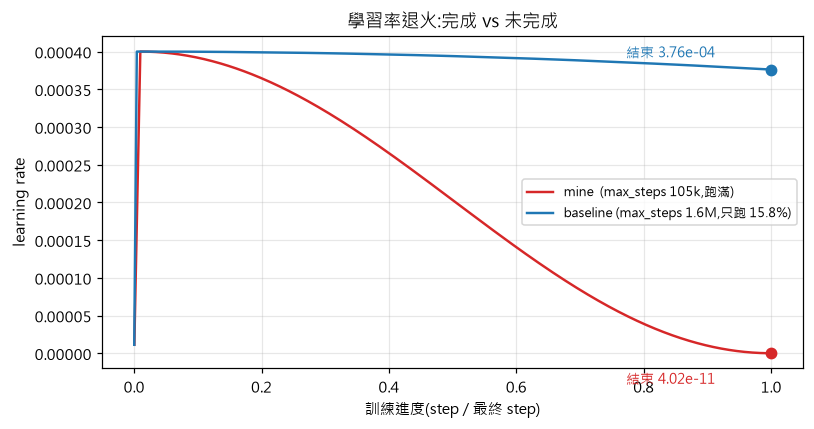

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4))

for n, d, c, dy in [("mine  (max_steps 105k,跑滿)", mine, "tab:red", -20),
                    ("baseline (max_steps 1.6M,只跑 15.8%)", base, "tab:blue", 8)]:
    s, v = ser(d, "lr-AdamW")
    ax.plot(s / s.max(), v, c=c, lw=1.6, label=n)
    ax.scatter([1.0], [v[-1]], c=c, s=45, zorder=5)
    ax.annotate("結束 %.2e" % v[-1], (1.0, v[-1]), textcoords="offset points",
                xytext=(-95, dy), fontsize=9, color=c)

ax.set_xlabel("訓練進度(step / 最終 step)")
ax.set_ylabel("learning rate")
ax.set_title("學習率退火:完成 vs 未完成")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

## 圖 3:LR 與訓練穩定性

把本次每個驗證點的 val_loss 對「當時的 LR」作圖 —— spike 隨 LR 下降而消失,
可讀出經驗穩定閾值,作為下一次實驗設定峰值 LR 的依據。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

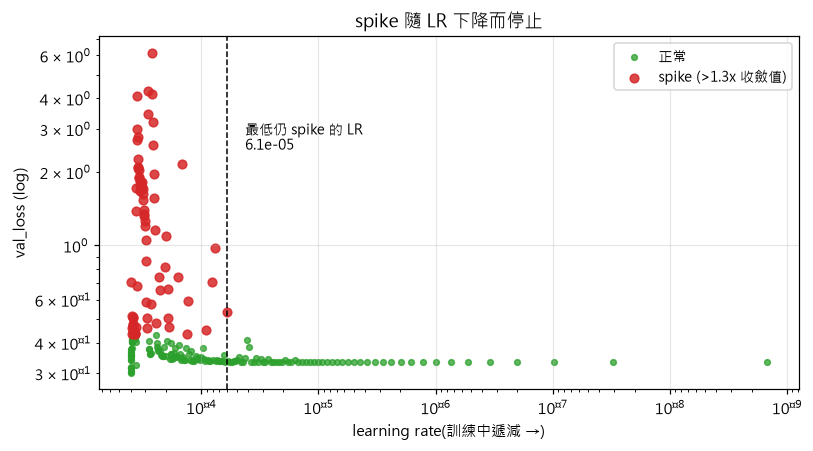

收斂水準            : 0.33211
spike 次數          : 76 / 231
最低仍 spike 的 LR  : 6.06e-05
→ 下次峰值 LR 建議 <= 6e-05


In [4]:
sv, v = ser(mine, "val_loss")
sl, l = ser(mine, "lr-AdamW")
lr_at = np.interp(sv, sl, l)          # 每個驗證點當時的 LR

lvl = np.median(v[-30:])              # 收斂後的水準
spike = v > lvl * 1.3

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(lr_at[~spike], v[~spike], s=14, c="tab:green", alpha=.75, label="正常")
ax.scatter(lr_at[spike], v[spike], s=32, c="tab:red", alpha=.85,
           label="spike (>1.3x 收斂值)")

if spike.any():
    thr = lr_at[spike].min()
    ax.axvline(thr, ls="--", c="k", lw=1)
    ax.annotate("最低仍 spike 的 LR\n%.1e" % thr, (thr, v.max() * .4),
                xytext=(12, 0), textcoords="offset points", fontsize=9)

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("learning rate(訓練中遞減 →)")
ax.set_ylabel("val_loss (log)")
ax.set_title("spike 隨 LR 下降而停止")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("收斂水準            : %.5f" % lvl)
print("spike 次數          : %d / %d" % (spike.sum(), len(v)))
if spike.any():
    print("最低仍 spike 的 LR  : %.2e" % lr_at[spike].min())
    print("→ 下次峰值 LR 建議 <= %.0e" % lr_at[spike].min())

## 圖 4:逐變數 val_RMSE

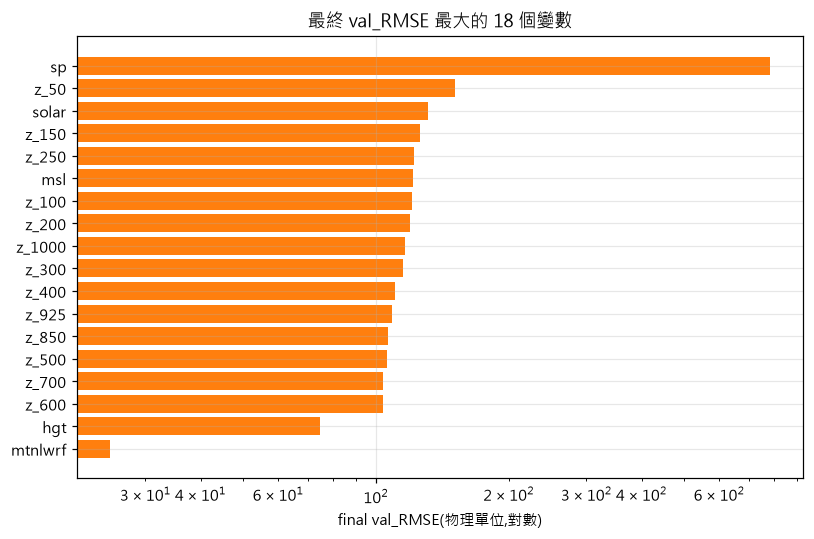

注意:各變數單位不同(Pa / m2s-2 / K ...),不可跨變數比大小。


In [5]:
per = {}
with open("run_mine_per_var.csv", newline="") as f:
    for r in csv.DictReader(f):
        per.setdefault(r["tag"], []).append((int(r["step"]), float(r["value"])))

final = {t: sorted(p)[-1][1] for t, p in per.items() if t.startswith("val_RMSE/")}
top = sorted(final.items(), key=lambda x: -x[1])[:18]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh([t.replace("val_RMSE/", "") for t, _ in top][::-1],
        [v for _, v in top][::-1], color="tab:orange")
ax.set_xscale("log")
ax.set_xlabel("final val_RMSE(物理單位,對數)")
ax.set_title("最終 val_RMSE 最大的 18 個變數")
plt.tight_layout()
plt.show()

print("注意:各變數單位不同(Pa / m2s-2 / K ...),不可跨變數比大小。")

## 摘要表(可貼進投影片)

In [3]:
def summ(d):
    s, v = ser(d, "val_loss")
    _, l = ser(d, "lr-AdamW")
    _, e = ser(d, "epoch")
    h = d["hours"][~np.isnan(d["hours"])]
    return dict(best=v.min(), bstep=int(s[v.argmin()]), final=v[-1],
                ep=int(e.max()), st=int(s.max()), lr0=l.max(), lr1=l[-1],
                hr=h.max() if len(h) else float("nan"))


a, b = summ(mine), summ(base)
rows = [
    ("最佳 val_loss", "%.5f (step %d)" % (a["best"], a["bstep"]),
                      "%.5f (step %d)" % (b["best"], b["bstep"])),
    ("最終 val_loss", "%.5f" % a["final"], "%.5f" % b["final"]),
    ("epochs", str(a["ep"]), str(b["ep"])),
    ("steps", "{:,}".format(a["st"]), "{:,}".format(b["st"])),
    ("牆鐘(小時)", "%.1f" % a["hr"], "%.1f" % b["hr"]),
    ("LR 峰值→結束", "%.1e → %.1e" % (a["lr0"], a["lr1"]),
                     "%.1e → %.1e" % (b["lr0"], b["lr1"])),
    ("LR 退火完成度", "%.0f%%" % ((1 - a["lr1"] / a["lr0"]) * 100),
                      "%.0f%%" % ((1 - b["lr1"] / b["lr0"]) * 100)),
]

w = max(len(r[0]) for r in rows)
print("%-*s  %26s  %26s" % (w, "", "mine (vt/vr, R=41)", "baseline (u/v, R=201)"))
print("-" * (w + 58))
for k, x, y in rows:
    print("%-*s  %26s  %26s" % (w, k, x, y))
print()
print("⚠️ val_loss 不可直接比較(變數表與網格不同)。")
print("   可比的是:LR 退火完成度、訓練穩定性、吞吐。")

                     mine (vt/vr, R=41)       baseline (u/v, R=201)
---------------------------------------------------------------------
最佳 val_loss         0.30065 (step 2269)       0.29061 (step 239645)
最終 val_loss                     0.33168                     0.29284
epochs                              231                          69
steps                           104,873                     252,160
牆鐘(小時)                              6.7                       199.6
LR 峰值→結束              4.0e-04 → 4.0e-11           4.0e-04 → 3.8e-04
LR 退火完成度                           100%                          6%

⚠️ val_loss 不可直接比較(變數表與網格不同)。
   可比的是:LR 退火完成度、訓練穩定性、吞吐。


---

# 短診斷(2026-08-04)

原始訓練梯度中位數 **3.8e6**、95.6% 的步驟被裁剪。跑兩組短診斷試圖歸因:

| | Job | 精度 | 峰值 LR | `max_steps` | 牆鐘 |
|---|---|---|---|---|---|
| 原始 | 233052 | bf16-mixed | 4e-4 | 105,000 | 6.7 h |
| **診斷 A** | 234729 | **fp32** | 4e-4 | **13,600** | 79 min |
| **診斷 B** | 234730 | bf16-mixed | **5e-5** | **13,600** | 53 min |

## 圖 5:梯度範數三者對照

左圖用全程資料會有長度造成的假象(原始跑 105k、診斷只跑 13.6k),
右圖把原始訓練**裁切到同一段 step** 才是公平比較。

(略過,檔案不存在:diag_fp32_s105k_curves.csv)


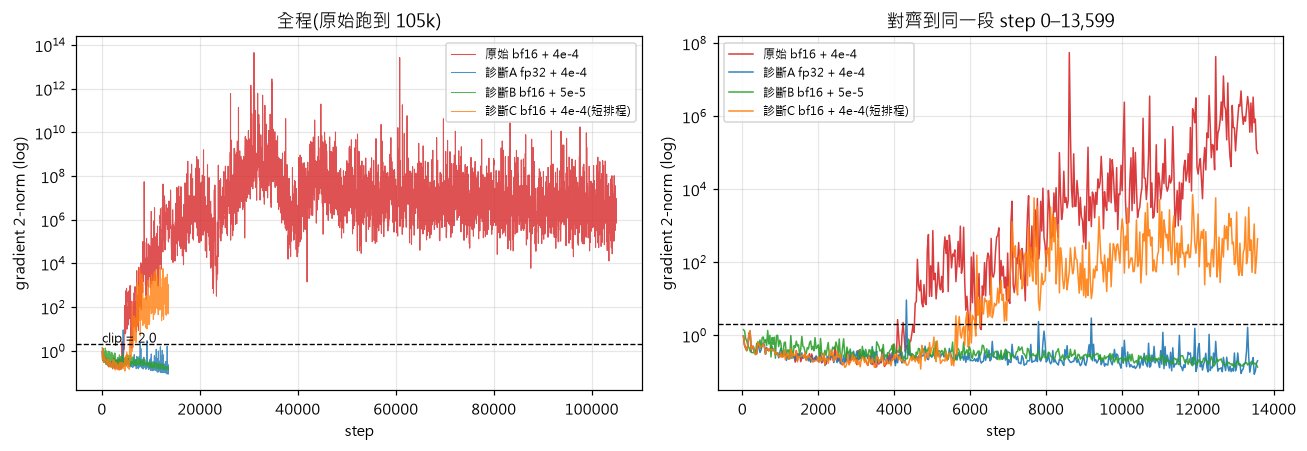


同一段 step 0–13599 的比較(裁掉原始訓練的後段,避免長度造成假象)
                                   梯度中位         梯度最大      >2.0     最佳val
------------------------------------------------------------------------
原始 bf16 + 4e-4                    147.2    5.515e+07     66.2%   0.30065
診斷A fp32 + 4e-4                  0.2275        9.229      0.6%   0.28932
診斷B bf16 + 5e-5                  0.2812        1.427      0.0%   0.28707
診斷C bf16 + 4e-4(短排程)              9.843         7099     56.2%   0.29943


In [12]:
import os

# 要比較的實驗:(顯示名稱, CSV 檔名, 顏色)。檔案不存在就自動略過,
# 所以新診斷跑完後只要把 CSV 放進本目錄、在這裡加一行即可。
CANDIDATES = [
    ("原始 bf16 + 4e-4", None,                     "tab:red"),    # mine,已在 cell 1 載入
    ("診斷A fp32 + 4e-4", "diag_fp32_curves.csv",   "tab:blue"),
    ("診斷B bf16 + 5e-5", "diag_lr5e-5_curves.csv", "tab:green"),
    ("診斷C bf16 + 4e-4(短排程)", "diag_C_curves.csv", "tab:orange"),
    ("A2 fp32 + 原始排程", "diag_fp32_s105k_curves.csv", "tab:purple"),
]

RUNS = []
for n, path, c in CANDIDATES:
    if path is None:
        RUNS.append((n, mine, c))
    elif os.path.exists(path):
        RUNS.append((n, load(path), c))
    else:
        print("(略過,檔案不存在:%s)" % path)

CUT = int(min(d["step"].max() for _, d, _ in RUNS[1:]))   # 最短的那一組決定比較範圍

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for n, d, c in RUNS:
    s, g = ser(d, "gradient_2norm")
    ax[0].semilogy(s, g, c=c, lw=.7, alpha=.8, label=n)
    m = s <= CUT
    ax[1].semilogy(s[m], g[m], c=c, lw=1.0, alpha=.9, label=n)

for a_, t in zip(ax, ["全程(原始跑到 105k)", "對齊到同一段 step 0–%s" % f"{CUT:,}"]):
    a_.axhline(2.0, ls="--", c="k", lw=.9)
    a_.set_xlabel("step")
    a_.set_ylabel("gradient 2-norm (log)")
    a_.set_title(t)
    a_.legend(fontsize=8)
ax[0].annotate("clip = 2.0", (0, 2.4), fontsize=8.5)

plt.tight_layout()
plt.show()


print("\n同一段 step 0–%d 的比較(裁掉原始訓練的後段,避免長度造成假象)" % CUT)
print("%-28s %10s %12s %9s %9s" % ("", "梯度中位", "梯度最大", ">2.0", "最佳val"))
print("-" * 72)
for n, d, _ in RUNS:
    s, g = ser(d, "gradient_2norm")
    sv, v = ser(d, "val_loss")
    seg = g[s <= CUT]
    vseg = v[sv <= CUT]
    print("%-28s %10.4g %12.4g %8.1f%% %9.5f"
          % (n, np.median(seg), seg.max(), 100 * (seg > 2).mean(), vseg.min()))

## 圖 6:診斷的混淆變因 —— **這兩組其實都不是單變數對照**

兩個診斷都把 `max_steps` 105,000 → 13,600 以縮短時間。但 cosine 的長度來自
[`lightning_modules.py`](../models/lightning_modules.py#L229) 的

```python
training_steps = int(self.trainer.estimated_stepping_batches)
```

而 Lightning 定義 `estimated_stepping_batches = min(每epoch步數 × max_epochs, max_steps)`。
**所以改 `max_steps` 就等於改 LR 軌跡** —— 診斷 A 同時變動了「精度 + LR 軌跡」,
診斷 B 同時變動了「峰值 LR + LR 軌跡」,兩者都無法單獨歸因。

> ⚠️ 改用 `max_epochs` 限制**同樣無效**:上式取 min,壓縮效果一模一樣。
> 唯一不影響排程的停止條件是 **`max_time`**(由 Timer callback 執行,不進上式)。
> `experiments/diag_fp32_sched105k.yaml` 就是照這個設計寫的。

右圖顯示:在三者 LR 都還在峰值的窗口內,**梯度幾乎完全重疊**。
原始訓練的惡化發生在 step 4,000–5,000 之間,而那正是診斷組的 LR 開始明顯下降的時候。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

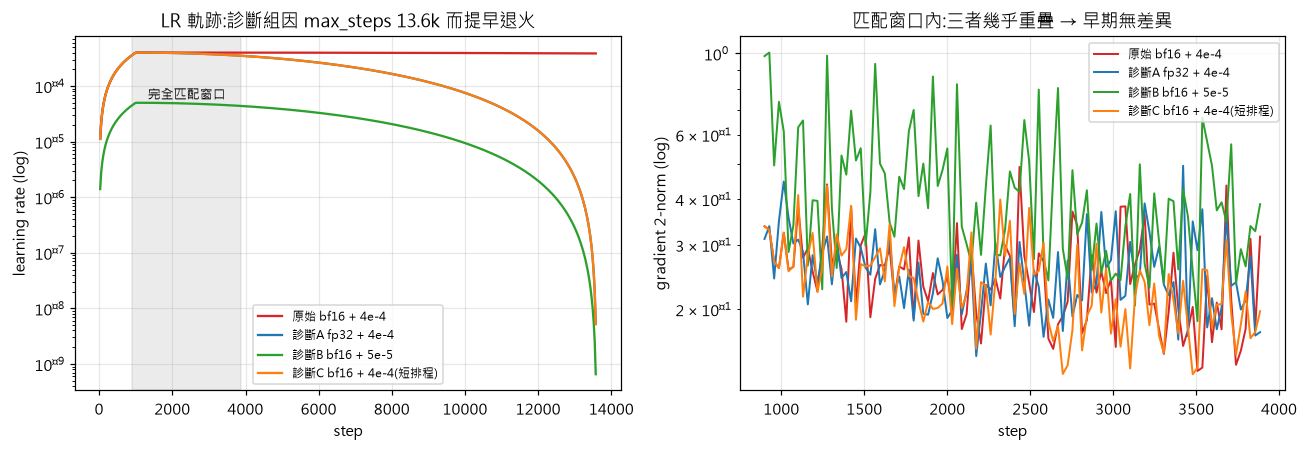

完全匹配窗口 step 898–3885(LR 都在峰值附近)
                             梯度中位         梯度最大
原始 bf16 + 4e-4             0.2416       0.4893
診斷A fp32 + 4e-4             0.244       0.4929
診斷B bf16 + 5e-5             0.393        1.005
診斷C bf16 + 4e-4(短排程)       0.2333       0.4349

原始訓練前 14k 步的逐千步演變(找出惡化的確切時點):
   step     0-999    中位     0.4174  最大       1.319
   step  1000-1999   中位     0.2612  最大      0.4383
   step  2000-2999   中位     0.2261  最大      0.4893
   step  3000-3999   中位     0.2042  最大      0.5686
   step  4000-4999   中位      2.254  最大       576.2  ← 跳升
   step  5000-5999   中位      72.15  最大       978.4
   step  6000-6999   中位      42.43  最大       877.3
   step  7000-7999   中位      231.8  最大   1.073e+04
   step  8000-8999   中位       3401  最大   5.515e+07
   step  9000-9999   中位       7308  最大   1.412e+05
   step 10000-10999  中位  1.102e+04  最大    3.55e+06
   step 11000-11999  中位  1.617e+04  最大   3.171e+06
   step 12000-12999  中位  2.517e+05  最大   4.279e+07
   step 13000-13999  中位  8.905e+0

In [13]:
# 左:同一段 step 內的 LR 軌跡 —— 看得出診斷組的排程被壓縮了
# 右:完全匹配的窗口(三者 LR 都還在峰值附近),梯度是否有差
LO, HI = 898, 3885                    # 診斷 A 的 LR 仍 > 3.5e-4 的區間

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for n, d, c in RUNS:
    s, l = ser(d, "lr-AdamW")
    m = s <= CUT
    ax[0].semilogy(s[m], l[m], c=c, lw=1.5, label=n)
ax[0].axvspan(LO, HI, color="k", alpha=.08)
ax[0].annotate("完全匹配窗口", ((LO + HI) / 2, 6e-5), ha="center", fontsize=8.5)
ax[0].set_xlabel("step")
ax[0].set_ylabel("learning rate (log)")
ax[0].set_title("LR 軌跡:診斷組因 max_steps 13.6k 而提早退火")
ax[0].legend(fontsize=8)

for n, d, c in RUNS:
    s, g = ser(d, "gradient_2norm")
    m = (s >= LO) & (s <= HI)
    ax[1].semilogy(s[m], g[m], c=c, lw=1.3, label=n)
ax[1].set_xlabel("step")
ax[1].set_ylabel("gradient 2-norm (log)")
ax[1].set_title("匹配窗口內:三者幾乎重疊 → 早期無差異")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


print("完全匹配窗口 step %d–%d(LR 都在峰值附近)" % (LO, HI))
print("%-22s %10s %12s" % ("", "梯度中位", "梯度最大"))
for n, d, _ in RUNS:
    s, g = ser(d, "gradient_2norm")
    seg = g[(s >= LO) & (s <= HI)]
    print("%-22s %10.4g %12.4g" % (n, np.median(seg), seg.max()))

print()
print("原始訓練前 14k 步的逐千步演變(找出惡化的確切時點):")
s, g = ser(mine, "gradient_2norm")
for lo in range(0, 14000, 1000):
    seg = g[(s >= lo) & (s < lo + 1000)]
    if len(seg):
        mark = "  ← 跳升" if 4000 <= lo < 5000 else ""
        print("   step %5d-%-5d  中位 %10.4g  最大 %11.4g%s"
              % (lo, lo + 999, np.median(seg), seg.max(), mark))

## 圖 7:哪一層先失控 —— 找出震央

`grad_2.0_norm/*` 記錄了**每一層**的梯度範數(191 層)。對每一層取 step 1,000–3,500
(全體都還健康)的中位數當基準,再找它**第一次超過基準 10 倍**的 step,就能還原
「誰先動手、往哪個方向擴散」。

架構的資料流是:

```
patch_embed → layer1 → DownSample → layer2 → layer3 → UpSample → layer4 → patch_recover
                 └──────────── U-Net skip ────────────────┘
```

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


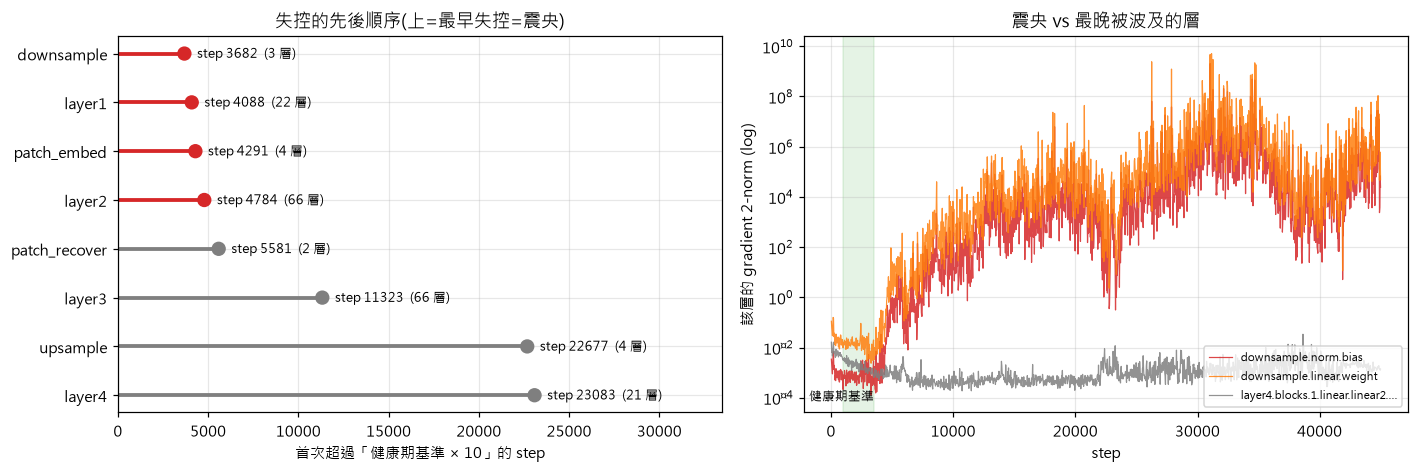

=== 最早失控的 8 層(震央)===
    首次超標step       健康期中位        全程最大  層
        3682   0.0006859   2.039e+09  downsample.norm.bias
        3682   0.0005608   3.858e+09  downsample.norm.weight
        3972     0.01346   5.109e+09  downsample.linear.weight
        3972   0.0002807   1.326e+06  layer2.blocks.0.norm1.bias
        3972   0.0002803   9.401e+06  layer2.blocks.0.norm1.weight
        3972   0.0002318   1.354e+06  layer2.blocks.0.norm2.bias
        3972   0.0002051    5.33e+06  layer2.blocks.0.norm2.weight
        3972    0.003381   7.566e+05  layer2.blocks.1.attention.proj.weight

=== 依模組:首次超標 step 的中位數(由早到晚)===
   downsample     step   3682   (3 層)
   layer1         step   4088   (22 層)
   patch_embed    step   4291   (4 層)
   layer2         step   4784   (66 層)
   patch_recover  step   5582   (2 層)
   layer3         step  11324   (66 層)
   upsample       step  22677   (4 層)
   layer4         step  23083   (21 層)

188 / 191 層最終都被波及。
資料流:patch_embed → layer1 → downsample → layer2 → layer3

In [14]:
import gzip

# 逐層梯度每步都記錄(191 層 × 3,620 點),原始 CSV 46 MB,
# 故只保留 step <= 45,000(所有「首次超標」事件都在此之前)並壓縮。
lay = {}
with gzip.open("run_mine_per_layer.csv.gz", "rt", newline="") as f:
    for r in csv.DictReader(f):
        lay.setdefault(r["tag"].replace("grad_2.0_norm/", ""), []).append(
            (int(r["step"]), float(r["value"])))
for p in lay.values():
    p.sort()

BASE_LO, BASE_HI, FACTOR = 1000, 3500, 10      # 健康期區間、判定倍數

first = []
for name, p in lay.items():
    base = [v for s, v in p if BASE_LO <= s <= BASE_HI]
    if len(base) < 5:
        continue
    b = np.median(base)
    if b <= 0:
        continue
    hit = [s for s, v in p if s > BASE_HI and v > FACTOR * b]
    if hit:
        first.append((hit[0], name, b, max(v for _, v in p)))
first.sort()


def group(n):
    for k in ("patch_embed", "downsample", "upsample", "layer1", "layer2",
              "layer3", "layer4", "patch_recover"):
        if k in n:
            return k
    return "其他"


by = {}
for s, n, _, _ in first:
    by.setdefault(group(n), []).append(s)
# y 軸依【失控先後】排序,由早到晚 —— 直接讀就是傳染順序
by = dict(sorted(by.items(), key=lambda x: np.median(x[1])))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

# 左:什麼時候失控(lollipop,越靠左越早)
names = list(by)[::-1]
med = [np.median(by[k]) for k in names]
cols = ["tab:red" if m < 5000 else "tab:gray" for m in med]
ax[0].hlines(names, 0, med, color=cols, lw=2.5)
ax[0].scatter(med, names, color=cols, s=70, zorder=5)
for i, (k, m) in enumerate(zip(names, med)):
    ax[0].text(m + 700, i, "step %d  (%d 層)" % (m, len(by[k])),
               va="center", fontsize=8.5)
ax[0].set_xlim(0, max(med) * 1.45)
ax[0].set_xlabel("首次超過「健康期基準 × %d」的 step" % FACTOR)
ax[0].set_title("失控的先後順序(上=最早失控=震央)")

# 右:震央那幾層 vs 最晚被波及的那層,實際的梯度曲線
show = [first[0][1], first[2][1],
        max(first, key=lambda x: x[0])[1]]
for n, c in zip(show, ["tab:red", "tab:orange", "tab:gray"]):
    s = np.array([x[0] for x in lay[n]])
    v = np.array([x[1] for x in lay[n]])
    ax[1].semilogy(s, v, lw=.8, c=c, alpha=.85,
                   label=n if len(n) < 34 else n[:31] + "...")
ax[1].axvspan(BASE_LO, BASE_HI, color="tab:green", alpha=.12)
ax[1].annotate("健康期基準", (BASE_HI, ax[1].get_ylim()[0] * 3),
               fontsize=8.5, ha="right")
ax[1].set_xlabel("step")
ax[1].set_ylabel("該層的 gradient 2-norm (log)")
ax[1].set_title("震央 vs 最晚被波及的層")
ax[1].legend(fontsize=7.5, loc="lower right")

plt.tight_layout()
plt.show()


print("=== 最早失控的 8 層(震央)===")
print("%12s %11s %11s  %s" % ("首次超標step", "健康期中位", "全程最大", "層"))
for s, n, b, mx in first[:8]:
    print("%12d %11.4g %11.4g  %s" % (s, b, mx, n))

print("\n=== 依模組:首次超標 step 的中位數(由早到晚)===")
for k, v in by.items():
    print("   %-14s step %6.0f   (%d 層)" % (k, np.median(v), len(v)))

print("\n%d / %d 層最終都被波及。" % (len(first), len(lay)))
print("資料流:patch_embed → layer1 → downsample → layer2 → layer3 "
      "→ upsample → layer4 → patch_recover")
print("       └───────────────── U-Net skip:layer1 直達 layer4 ──────────────┘")